In [ ]:
!pip install transformers --upgrade -q
!pip install scikit-learn xgboost shap imbalanced-learn --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 31.7 MB/s eta 0:00:00


In [2]:
import kagglehub
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [00:13<00:00, 98.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [3]:
import pandas as pd
import os

# Direct path to the EXACT file
file_path = os.path.join(path, 'accepted_2007_to_2018Q4.csv.gz')

# Load it (it's gzipped so specify compression)
df = pd.read_csv(file_path,
                 compression='gzip',
                 nrows=100000,
                 low_memory=False)

print(f" Loaded: {df.shape}")

 Loaded: (100000, 151)


In [ ]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
th = 0.8
missing_values = df.isna().sum()
cols = missing_values[missing_values > th].index
df_clean = df.drop(columns = cols)
df_clean

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,MORTGAGE,...,76.9,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,MORTGAGE,...,97.4,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,MORTGAGE,...,100.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,MORTGAGE,...,100.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,MORTGAGE,...,96.6,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,62197780,20000.0,20000.0,20000.0,36 months,11.53,659.81,B,B5,MORTGAGE,...,100.0,0.0,0.0,144317.0,47788.0,11000.0,34577.0,N,Cash,N
99996,61374218,3000.0,3000.0,3000.0,36 months,11.53,98.98,B,B5,RENT,...,100.0,0.0,0.0,42995.0,21648.0,19200.0,18995.0,N,Cash,N
99997,60903843,14000.0,14000.0,14000.0,60 months,17.57,352.25,D,D4,RENT,...,100.0,1.0,0.0,54910.0,32505.0,14300.0,20510.0,N,Cash,N
99998,61973344,30000.0,30000.0,30000.0,36 months,12.69,1006.35,C,C2,MORTGAGE,...,100.0,0.0,0.0,215386.0,54169.0,63700.0,23186.0,N,Cash,N


In [5]:
df_clean['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default'], dtype=object)

In [6]:
df_clean = df_clean[df_clean['loan_status'].isin(['Fully Paid','Charged Off'])]
df_clean['target']=(df_clean['loan_status']== 'Charged Off').astype(int)
print((df_clean['target'] ==1).sum())
print(df_clean['target'].mean()*100)
print(df_clean['target'].head(50))
df_clean['target']

17603
20.02821676849734
0     0
1     0
2     0
4     0
5     0
6     0
7     0
8     0
9     0
12    0
13    1
14    0
15    0
16    0
17    0
19    0
20    0
21    0
22    0
23    0
24    0
25    1
26    0
27    0
28    0
29    0
30    1
31    1
32    0
33    1
35    0
36    0
37    0
38    0
39    0
40    0
41    1
43    0
44    0
45    0
46    0
47    0
49    0
50    0
54    0
56    0
57    0
58    0
59    0
60    1
Name: target, dtype: int64


/tmp/ipython-input-1415/1938325470.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['target']=(df_clean['loan_status']== 'Charged Off').astype(int)


,target
0,0
1,0
2,0
4,0
5,0
...,...
99994,0
99995,0
99996,0
99997,0


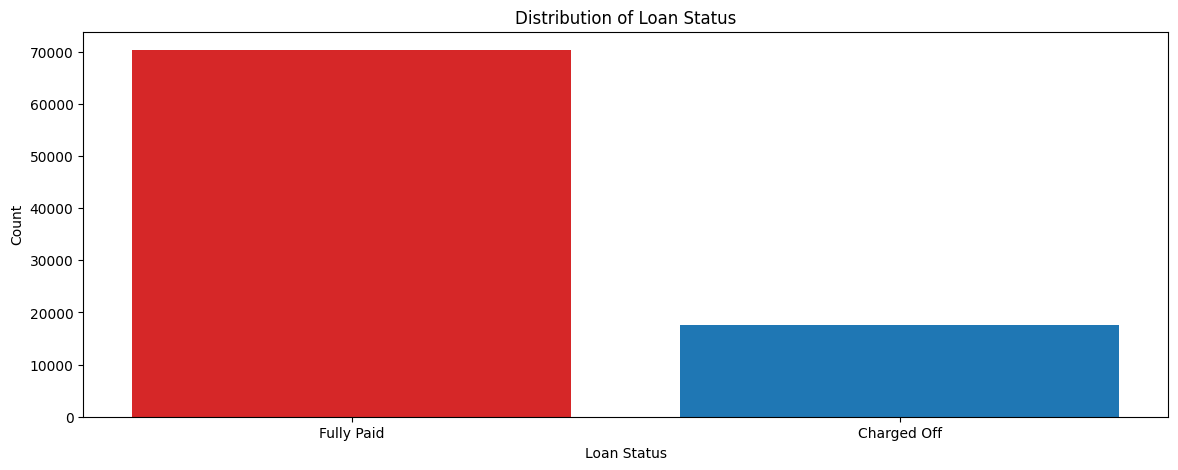

In [7]:
import matplotlib.pyplot as plt

target_counts = df_clean['target'].value_counts()
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['tab:red', 'tab:blue']
ax.bar(['Fully Paid', 'Charged Off'], target_counts, color=bar_colors)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status')
plt.show()

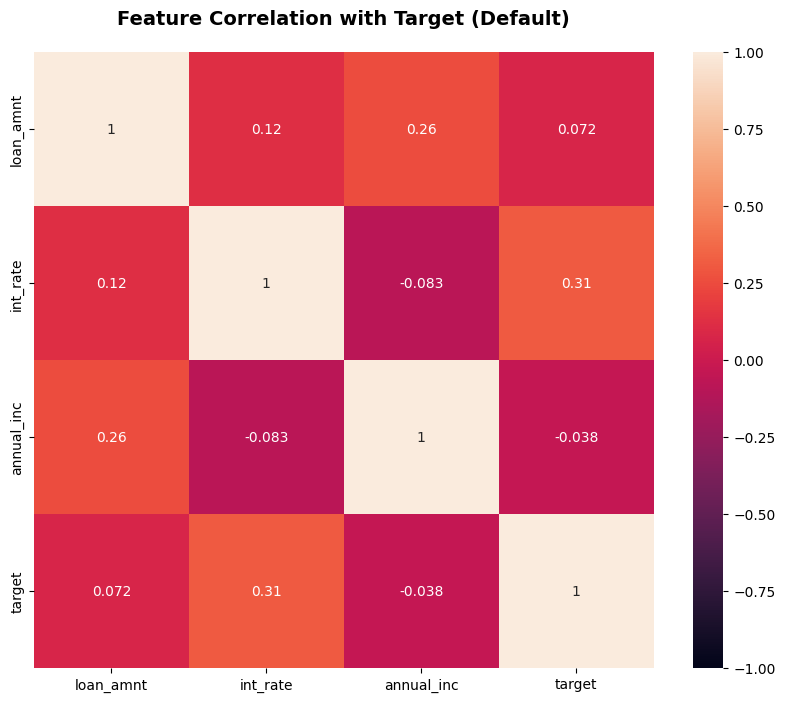

In [8]:
import seaborn as sns
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'target']
corr_matrix = df_clean[cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True,vmin=-1, vmax=1)
ax.set_title('Feature Correlation with Target (Default)', fontsize=14, fontweight='bold', pad=20)
plt.show()

In [9]:
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

text_columns = ['emp_title', 'title', 'desc', 'purpose']
existing_text_cols = [col for col in text_columns if col in df_clean.columns]
print(f"Available text columns:")
for col in existing_text_cols:
    non_null = df_clean[col].notna().sum()
    pct = non_null / len(df_clean) * 100
    print(f"   • {col}: {non_null:,} non-null ({pct:.1f}%)")

# Text cleaning function
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  text = text.strip()

  return text

print(" Cleaning and combining text")

df_clean['combined_text'] = ''
for col in existing_text_cols:
    print(f"   Processing {col}...")
    df_clean['combined_text'] += df_clean[col].apply(clean_text) + ' '

df_clean['combined_text'] = df_clean['combined_text'].str.strip()

min_text_length = 10
df_clean = df_clean[df_clean['combined_text'].str.len() >= min_text_length].copy()

print("Text processing complete")
print(f" Rows with sufficient text: {len(df_clean):,}")
print(f" Average text length: {df_clean['combined_text'].str.len().mean():.0f} characters")
print(f" Sample text:")
print(f"'{df_clean['combined_text'].iloc[0][:150]}...'")

# ============================================================================
# STEP 4: NUMERICAL FEATURES
# ============================================================================

print("\n🔢 STEP 4: Numerical Feature Selection")
print("-"*70)

# Select numerical columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove IDs and target
exclude_cols = ['id', 'member_id', 'target', 'policy_code','recoveries', 'collection_recovery_fee', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int','loan_status','last_fico_range_low','last_fico_range_high']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# Remove columns with too many NaNs
numerical_cols = [col for col in numerical_cols
                  if df_clean[col].notna().sum() / len(df_clean) > 0.5]

print(f" Selected {len(numerical_cols)} numerical features")
print(f"   Examples: {numerical_cols[:10]}")

# Handle missing values in numerical columns (fill with median)
print(f" Handling missing values...")
for col in numerical_cols:
    if df_clean[col].isna().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

print(f" Missing values filled with median")

# ============================================================================
# STEP 5: PREPARE FEATURES FOR MODELING
# ============================================================================

print("\n  STEP 5: Preparing Final Features")


# Extract features
X_text = df_clean['combined_text'].values
X_numerical = df_clean[numerical_cols].values
y = df_clean['target'].values
df_clean.drop(columns='loan_status', inplace=True)


print(f" Features prepared:")
print(f"   Text features shape: {X_text.shape}")
print(f"   Numerical features shape: {X_numerical.shape}")
print(f"   Target shape: {y.shape}")
print(f"   Default rate: {y.mean()*100:.2f}%")

# ============================================================================
# STEP 6: TRAIN/TEST SPLIT
# ============================================================================

print("\n  STEP 6: Train/Test Split")

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numerical, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f" Split complete:")
print(f"   Training set: {len(X_text_train):,} samples ({len(X_text_train)/len(X_text)*100:.0f}%)")
print(f"   Test set: {len(X_text_test):,} samples ({len(X_text_test)/len(X_text)*100:.0f}%)")
print(f"   Train default rate: {y_train.mean()*100:.2f}%")
print(f"   Test default rate: {y_test.mean()*100:.2f}%")

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

Available text columns:
   • purpose: 87,891 non-null (100.0%)
 Cleaning and combining text
   Processing purpose...


/tmp/ipython-input-1415/1140769979.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined_text'] = ''
/tmp/ipython-input-1415/1140769979.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined_text'] += df_clean[col].apply(clean_text) + ' '
/tmp/ipython-input-1415/1140769979.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

Text processing complete
 Rows with sufficient text: 79,858
 Average text length: 16 characters
 Sample text:
'debt consolidation...'

🔢 STEP 4: Numerical Feature Selection
----------------------------------------------------------------------
 Selected 46 numerical features
   Examples: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths']
 Handling missing values...
 Missing values filled with median

  STEP 5: Preparing Final Features
 Features prepared:
   Text features shape: (79858,)
   Numerical features shape: (79858, 46)
   Target shape: (79858,)
   Default rate: 20.07%

  STEP 6: Train/Test Split
 Split complete:
   Training set: 63,886 samples (80%)
   Test set: 15,972 samples (20%)
   Train default rate: 20.07%
   Test default rate: 20.07%


In [10]:
default_texts = df_clean[df_clean['target']==1]['combined_text']
non_default_texts = df_clean[df_clean['target']==0]['combined_text']

print("Sample default text:", default_texts.sample(3, random_state=42).values)
print("Sample non-default text:", non_default_texts.sample(3, random_state=42).values)

Sample default text: ['debt consolidation' 'debt consolidation' 'credit card']
Sample non-default text: ['debt consolidation' 'debt consolidation' 'debt consolidation']


In [11]:
default_counts = default_texts.value_counts().head(10)
non_default_counts = non_default_texts.value_counts().head(10)

print("Top default texts:\n", default_counts)
print("\nTop non-default texts:\n", non_default_counts)


Top default texts:
 combined_text
debt consolidation    10834
credit card            3609
home improvement       1000
major purchase          338
small business          234
renewable energy         11
Name: count, dtype: int64

Top non-default texts:
 combined_text
debt consolidation    38810
credit card           18421
home improvement       4586
major purchase         1427
small business          545
renewable energy         43
Name: count, dtype: int64


In [12]:
import numpy as np

for col in df_clean.select_dtypes(include=['int64','float64']):
    corr = np.corrcoef(df_clean[col], df_clean['target'])[0,1]
    if abs(corr) > 0.8:
        print(col, corr)

target 1.0


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [13]:
leakage_cols = [
    'recoveries', 'collection_recovery_fee', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int','loan_status']
k = []
for i in leakage_cols :
  if i in numerical_cols  :
    k.append(i)
print(k)

[]


In [14]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel

class BertEmbedding():
  def __init__(self, max_length=128):
    self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {self.device}")
    self.model = BertModel.from_pretrained('bert-base-uncased').to(self.device)
    self.max_length = max_length

  def embeddings(self, text, batch_size=32):
    embedding_tensors = [] # Collect PyTorch tensors
    for i in range(0, len(text), batch_size):
      batch = text[i:i+batch_size].tolist() # Ensure tokenizer receives a list of strings

      input_tokens = self.tokenizer(
          batch,
          return_tensors='pt',
          padding=True,
          truncation=True,
          max_length=self.max_length
      )

      input_tokens = {k: v.to(self.device) for k, v in input_tokens.items()}

      with torch.no_grad():
          output = self.model(**input_tokens).last_hidden_state[:,0,:]
      embedding_tensors.append(output)



    return torch.cat(embedding_tensors, dim=0)

bert = BertEmbedding(max_length = 128)
x_train_bert = bert.embeddings(X_text_train, batch_size=32)
x_test_bert = bert.embeddings(X_text_test, batch_size=32)

# Concatenate numerical and BERT embeddings.
# Move BERT embeddings to CPU and convert to NumPy before concatenating with NumPy arrays.
X_train_bert_combined = np.concatenate([X_num_train_scaled, x_train_bert.cpu().numpy()], axis=1)
X_test_bert_combined = np.concatenate([X_num_test_scaled, x_test_bert.cpu().numpy()], axis=1)
print(f"Shape of combined training data (X_train_bert_combined): {X_train_bert_combined.shape}")
print(f"Shape of combined test data (X_test_bert_combined): {X_test_bert_combined.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Using device: cpu


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of combined training data (X_train_bert_combined): (63886, 814)
Shape of combined test data (X_test_bert_combined): (15972, 814)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=500,  # Top 500 words
    min_df=5,          # Word must appear in at least 5 documents
    max_df=0.8,        # Ignore words in >80% of documents
    ngram_range=(1, 2)) # Unigrams and bigrams
x_train_transform = tfidf.fit_transform(X_text_train)
x_test_transform = tfidf.transform(X_text_test)
x_train_tfidf = np.concatenate([X_num_train_scaled, x_train_transform.toarray()], axis=1)
x_test_tfidf = np.concatenate([X_num_test_scaled, x_test_transform.toarray()], axis=1)

In [ ]:
pip install --upgrade shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.7
    Uninstalling slicer-0.0.7:
      Successfully uninstalled slicer-0.0.7
  Attempting uninstall: shap
    Found existing installation: shap 0.42.1
    Uninstalling shap-0.42.1:
      Successfully uninstalled shap-0.42.1


In [16]:
import shap
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix , precision_recall_curve , roc_curve , average_precision_score
import numpy as np
import matplotlib.pyplot as plt

class train_bert_tfidf():
  def __init__(self, x_train, x_text, y_train, y_test):
    self.x_train = x_train
    self.x_text = x_text
    self.y_train = y_train
    self.y_test = y_test
    self.model = None # Initialize model as None

  def tune_train_model(self):
    params = param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
    negative_samples = (self.y_train == 0).sum()
    positive_samples = (self.y_train == 1).sum()
    scale_pos_weight = negative_samples / positive_samples
    xgboost =xgb.XGBClassifier(
            scale_pos_weight=scale_pos_weight,  # Handle imbalance
            random_state=42,
            eval_metric='auc')
    score = RandomizedSearchCV(xgboost,params,cv=5,scoring='roc_auc')
    score.fit(self.x_train, self.y_train)
    print(score.best_params_)
    self.model = score.best_estimator_ # Assign to self.model


  def predict(self):
    if self.model is None:
      raise ValueError("Model has not been trained. Call tune_train_model first.")
    pred_proba = self.model.predict_proba(self.x_text)[:,1]
    return  pred_proba

  def evaluate(self):
    pred_proba = self.predict()

    precision, recall, thresholds = precision_recall_curve(self.y_test, pred_proba)


    scores = precision[:-1] * recall[:-1]
    threshold = thresholds[np.argmax(scores)]
    pred = (pred_proba >= threshold).astype(int)

    metrics = {
       'threshold': threshold,
       'average_precision_score' : average_precision_score(self.y_test, pred),
       'recall_score': recall_score(self.y_test, pred),
       'roc_auc_score': roc_auc_score(self.y_test, pred_proba)
    }
    return metrics, pred_proba, pred

model_tfidf = train_bert_tfidf(x_train_tfidf, x_test_tfidf, y_train, y_test)
model_tfidf.tune_train_model()
metrics, pred_proba,_ = model_tfidf.evaluate()
print(f"metrics for tfidf model: {metrics}")

model_bert = train_bert_tfidf(X_train_bert_combined, X_test_bert_combined, y_train, y_test)
model_bert.tune_train_model()
metrics, pred_proba,_ = model_bert.evaluate()
print(f"metrics for bert model: {metrics}")

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
metrics for tfidf model: {'threshold': np.float32(0.42179456), 'average_precision_score': 0.28419662540155816, 'recall_score': 0.7950078003120125, 'roc_auc_score': 0.7430134022154182}
{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
metrics for bert model: {'threshold': np.float32(0.42793685), 'average_precision_score': 0.2865179610912534, 'recall_score': 0.7706708268330733, 'roc_auc_score': 0.7411349120997032}


In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt

class xai():
  def __init__(self, model, x_test, feature_names):
    self.model = model
    self.x_test = x_test
    self.feature_names = feature_names
    self.explainer = shap.TreeExplainer(self.model)
    self.all_shap_values = self.explainer.shap_values(self.x_test)

    if isinstance(self.explainer.expected_value, list):
        self.expected_value_for_waterfall = self.explainer.expected_value[1]
    else:
        self.expected_value_for_waterfall = self.explainer.expected_value

  def plot_waterfall(self, instance_index=0):
    # Reshape to 2D as SHAP requires 2D input
    single_instance = self.x_test[instance_index].reshape(1, -1)
    shap_values_for_single_instance = self.explainer.shap_values(single_instance)
    
    # Handle both list and array return types
    if isinstance(shap_values_for_single_instance, list):
        shap_values_class1_for_instance = shap_values_for_single_instance[1][0]
    else:
        shap_values_class1_for_instance = shap_values_for_single_instance[0]

    explanation = shap.Explanation(
        values=shap_values_class1_for_instance,
        base_values=self.expected_value_for_waterfall,
        data=self.x_test[instance_index],
        feature_names=self.feature_names
    )
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot for Instance {instance_index}')

  def plot_summary(self):
    shap.summary_plot(self.all_shap_values, self.x_test, feature_names=self.feature_names, show=False, class_inds=1)
    plt.title('SHAP Summary Plot (Class 1)')

all_feature_names = numerical_cols + list(tfidf.get_feature_names_out())
plt.figure(figsize=(20, 8))
explainable = xai(model_tfidf.model, x_test_tfidf, all_feature_names)

plt.subplot(1, 2, 1)
explainable.plot_summary()

plt.subplot(1, 2, 2)
explainable.plot_waterfall(instance_index=0)

plt.tight_layout()
plt.show()

ValueError: Please reshape the input data into 2-dimensional matrix.

{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
{'threshold': np.float32(0.445842), 'average_precision_score': 0.2907701835689613, 'recall_score': 0.7650546021840874, 'roc_auc_score': 0.7417886793015387}


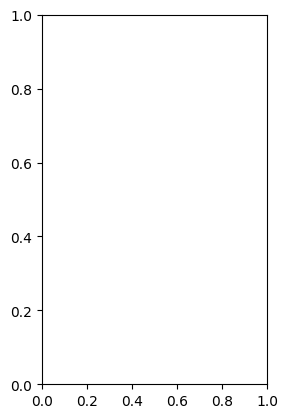

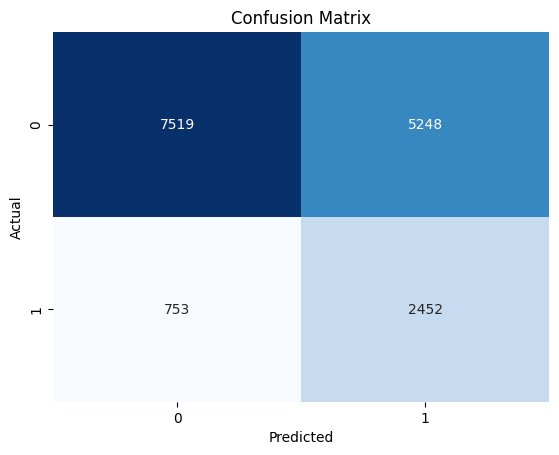

<Figure size 640x480 with 0 Axes>

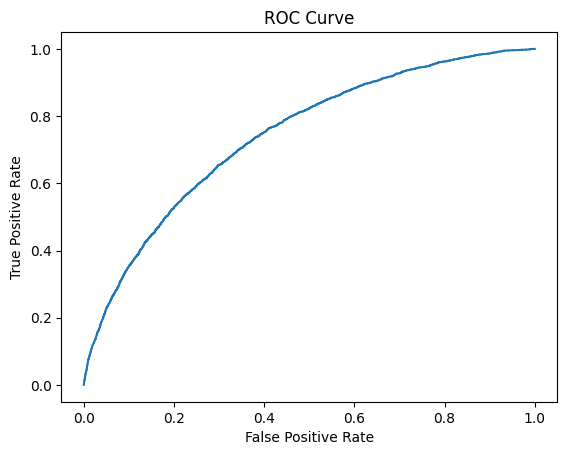

<Figure size 640x480 with 0 Axes>

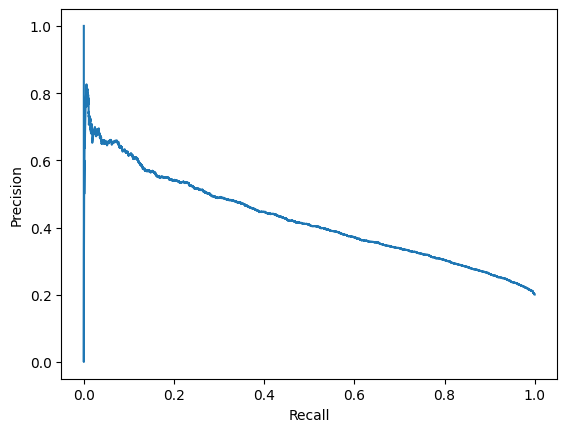

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, roc_curve as sk_roc_curve, precision_recall_curve as sk_precision_recall_curve

def plot_confusion_matrix(y_test, pred):
  cm = sk_confusion_matrix(y_test, pred)
  plt.figure()
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()
  return plt.gcf()

def plot_roc_auc_curve(pred_proba, y_test):
  fpr, tpr, thresholds = sk_roc_curve(y_test, pred_proba)
  plt.figure()
  plt.plot(fpr, tpr, label='ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.show()
  return plt.gcf()

def plot_pr_curve(pred_proba, y_test):
  precision, recall, thresholds = sk_precision_recall_curve(y_test, pred_proba)
  plt.figure()
  plt.plot(recall, precision, label='PR curve')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.show()
  return plt.gcf()

# Create a new instance of the model trainer
class_calling = train_bert_tfidf(x_train_tfidf, x_test_tfidf, y_train, y_test)

# Initialize and train the model within this new instance
class_calling.tune_train_model()

# Now evaluate the model and get predictions
metrics_new_instance, pred_proba, pred = class_calling.evaluate()
print(metrics_new_instance)

# Plot the curves using the predictions from this instance
cm_plot = plot_confusion_matrix(y_test, pred)
roc_plot = plot_roc_auc_curve(pred_proba, y_test)
pr_plot = plot_pr_curve(pred_proba, y_test)